https://developer.imdb.com/non-commercial-datasets/

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
title_basics = pd.read_csv("title.basics.tsv", sep='\t')

<ipython-input-6-96dcfc0aa8fe>:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  title_basics = pd.read_csv(path_fold + "/title.basics.tsv", sep='\t')


In [ ]:
title_basics.shape

(11276757, 9)

In [ ]:
title_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"


In [ ]:
data = title_basics[title_basics['titleType']=='movie']
data.shape

(699169, 9)

In [ ]:
del title_basics

In [ ]:
title_akas = pd.read_csv("title.akas.tsv", sep='\t')

In [ ]:
title_akas.head()

,titleId,ordering,title,region,language,types,attributes,isOriginalTitle
0,tt0000001,1,Carmencita,\N,\N,original,\N,1
1,tt0000001,2,Carmencita,DE,\N,\N,literal title,0
2,tt0000001,3,Carmencita,US,\N,imdbDisplay,\N,0
3,tt0000001,4,Carmencita - spanyol tánc,HU,\N,imdbDisplay,\N,0
4,tt0000001,5,Καρμενσίτα,GR,\N,imdbDisplay,\N,0


In [ ]:
title_akas = title_akas.rename(columns={'titleId':'tconst'})

In [ ]:
title_akas['region'].unique()

array(['\\N', 'DE', 'US', 'HU', 'GR', 'RU', 'UA', 'JP', 'RO', 'FR', 'GB',
       'CA', 'PT', 'MX', 'AU', 'IT', 'ES', 'FI', 'UY', 'AR', 'PL', 'BG',
       'RS', 'BR', 'TR', 'SK', 'XWW', 'DK', 'XEU', 'CZ', 'SE', 'NZ', 'KZ',
       'NO', 'XYU', 'AT', 'VE', 'CSHH', 'SI', 'SUHH', 'IN', 'NL', 'LT',
       'HR', 'TW', 'CN', 'CO', 'IR', 'SG', 'BE', 'EC', 'IE', 'VN', 'PH',
       'DZ', 'CH', 'XWG', 'BF', 'HK', 'XSA', 'EE', 'IS', 'PR', 'DDDE',
       'IL', 'EG', 'XKO', 'CL', 'JM', 'KR', 'PE', 'BY', 'GE', 'BA', 'DO',
       'TH', 'AE', 'ZA', 'PA', 'TJ', 'XSI', 'MY', 'UZ', 'AZ', 'LV', 'ID',
       'PK', 'BD', 'CU', 'AL', 'BO', 'XAS', 'NG', 'YUCS', 'GT', 'PY',
       'SV', 'CR', 'KP', 'BUMM', 'MM', 'XPI', 'BJ', 'CM', 'KG', 'MA',
       'GL', 'MN', 'LI', 'LU', 'MZ', 'MK', 'BM', 'MD', 'ME', 'LB', 'IQ',
       'TM', 'TN', 'HT', 'AM', 'CI', 'LK', 'NP', 'QA', 'SY', 'TO', 'CG',
       'SN', 'GH', 'JO', 'NE', 'GN', 'VDVN', 'TD', 'SO', 'SD', 'MC', 'TT',
       'GA', 'BS', 'LY', 'AO', 'KH', 'MR', 'AF', 'MG'

In [ ]:
title_akas['region'].value_counts().head(15)

\N     11326514
JP      4968045
DE      4966601
FR      4951319
IN      4900668
ES      4867297
IT      4845926
PT      4758532
US      1578127
GB       500685
CA       284211
XWW      195387
AU       180024
BR       131988
RU       116478
Name: region, dtype: int64

In [ ]:
title_akas[(title_akas['region']=="JP")]

,tconst,ordering,title,region,language,types,attributes,isOriginalTitle
7,tt0000001,8,カルメンチータ,JP,ja,imdbDisplay,\N,0
15,tt0000002,8,道化師と犬,JP,ja,imdbDisplay,\N,0
17,tt0000003,10,哀れなピエロ,JP,ja,imdbDisplay,\N,0
33,tt0000004,8,一杯のビール,JP,ja,imdbDisplay,\N,0
54,tt0000007,11,キネトグラフの前のコーベットとコートニー,JP,ja,imdbDisplay,\N,0
...,...,...,...,...,...,...,...,...
50548201,tt9916844,7,エピソード #3.15,JP,ja,\N,\N,0
50548209,tt9916846,7,エピソード #3.18,JP,ja,\N,\N,0
50548217,tt9916848,7,エピソード #3.17,JP,ja,\N,\N,0
50548225,tt9916850,7,エピソード #3.19,JP,ja,\N,\N,0


In [ ]:
data = pd.merge(data, title_akas, how='left', on='tconst')

In [ ]:
data.shape

(3405152, 16)

In [ ]:
del title_akas

In [ ]:
# title_episode  не используем, так как мы оставили в выборке только фильмы

In [ ]:
title_ratings = pd.read_csv("title.ratings.tsv", sep='\t')

In [ ]:
data = pd.merge(data, title_ratings, how='left', on='tconst')

In [ ]:
del title_ratings

In [ ]:
title_crew = pd.read_csv("title.crew.tsv", sep='\t')

In [ ]:
data = pd.merge(data, title_crew, how='left', on='tconst')

In [ ]:
del title_crew

In [ ]:
data.isna().sum()

tconst                  0
titleType               0
primaryTitle            0
originalTitle           0
isAdult                 0
startYear               0
endYear                 0
runtimeMinutes          0
genres                  0
ordering             1618
title                1618
region               1678
language             1618
types                1618
attributes           1618
isOriginalTitle      1618
averageRating      894684
numVotes           894684
directors           31622
writers             31622
dtype: int64

Так как мы хотим построить модель, прогнозирующую !!!!рейтинг (количество голосов)!!!! фильма, удалим наблюдения, в которых целевая переменная пустая.

In [ ]:
data = data[data['averageRating'].isna() == False]

In [ ]:
data.shape

(2510468, 20)

In [ ]:
data['genres'].value_counts().head(10)

Drama                   326515
Comedy                  147314
Documentary             135492
Drama,Romance            91390
Comedy,Drama             84929
Comedy,Drama,Romance     59858
Comedy,Romance           55067
Horror                   48769
Action,Crime,Drama       40924
Crime,Drama              36348
Name: genres, dtype: int64

Видим, что для некоторых фильмов несколько жанров записаны через запятую.

In [ ]:
genres = list(data['genres'])
genres[:10]

['Romance',
 'Romance',
 'Romance',
 'Romance',
 'Romance',
 'Documentary,News,Sport',
 'Documentary,News,Sport',
 'Documentary,News,Sport',
 '\\N',
 '\\N']

In [ ]:
genres_unique = []
for i in genres:
    genres_unique.extend(i.split(','))
genres = list(genres_unique)    # Сохранили упоминания жанров с повторами
genres_unique = list(set(genres_unique))   # Сохранили только уникальные значения переменной
print(genres_unique)

['Drama', 'Film-Noir', 'Biography', 'War', 'News', 'Fantasy', 'Sport', 'Animation', 'Family', 'Western', 'Talk-Show', 'History', '\\N', 'Adult', 'Musical', 'Music', 'Game-Show', 'Comedy', 'Adventure', 'Reality-TV', 'Documentary', 'Mystery', 'Crime', 'Thriller', 'Action', 'Sci-Fi', 'Horror', 'Romance']


In [ ]:
pd.Series(genres).value_counts()

Drama          1277413
Comedy          687925
Action          379933
Romance         352835
Crime           325418
Thriller        289333
Adventure       269479
Horror          242756
Documentary     220659
Mystery         156456
Fantasy         112093
Family          108668
Biography       100540
Sci-Fi           96269
History          84544
Animation        80694
War              70855
Music            63530
Western          59044
Musical          50482
Sport            34810
\N               33133
Adult            18400
Film-Noir        17865
News              2625
Reality-TV         360
Talk-Show           75
Game-Show           30
dtype: int64

In [ ]:
data[['genre1', 'genre2', 'genre3']] = data['genres'].str.split(',',expand=True).rename(columns={0:'genre1', 1:'genre2', 2:'genre3'})
data.head(10)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,ordering,...,types,attributes,isOriginalTitle,averageRating,numVotes,directors,writers,genre1,genre2,genre3
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,1.0,...,original,\N,1.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None
1,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,2.0,...,imdbDisplay,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None
2,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,3.0,...,imdbDisplay,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None
3,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,4.0,...,imdbDisplay,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None
4,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,5.0,...,\N,literal title,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None
5,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",1.0,...,original,\N,1.0,5.2,540.0,nm0714557,\N,Documentary,News,Sport
6,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",2.0,...,imdbDisplay,\N,0.0,5.2,540.0,nm0714557,\N,Documentary,News,Sport
7,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",3.0,...,imdbDisplay,\N,0.0,5.2,540.0,nm0714557,\N,Documentary,News,Sport
8,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,1.0,...,original,\N,1.0,4.4,18.0,nm0063413,"nm0063413,nm0657268,nm0675388",\N,None,None
9,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,2.0,...,imdbDisplay,\N,0.0,4.4,18.0,nm0063413,"nm0063413,nm0657268,nm0675388",\N,None,None


In [ ]:
# график топ-5 жанров
top_5_genres = df_genres.nlargest(5)
plt.figure(figsize=(10, 6))
plt.bar(top_5_genres.index, top_5_genres.values, color='skyblue')
plt.title('Top 5 Most Popular Movie Genres')
plt.xlabel('Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

In [ ]:
data['averageRating'].describe()

count    2.510468e+06
mean     6.154298e+00
std      1.221706e+00
min      1.000000e+00
25%      5.400000e+00
50%      6.300000e+00
75%      7.000000e+00
max      1.000000e+01
Name: averageRating, dtype: float64

In [ ]:
a = (10 - 1) / 5
a

1.8

In [ ]:
# Перекодирование рейтинга. Из 10-бальной шкалы сделаем 5-бальную шкалу.
data['rating_5'] = None
c = 1  # так как минимум равен 1
d = c + a  # прибавляем шаг
for i in range(1,6):
    data.loc[(data['averageRating']>=c)&(data['averageRating']<d), 'rating_5'] = i
    c = d
    d = c + a
data.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,ordering,...,attributes,isOriginalTitle,averageRating,numVotes,directors,writers,genre1,genre2,genre3,rating_5
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,1.0,...,\N,1.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None,3
1,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,2.0,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None,3
2,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,3.0,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None,3
3,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,4.0,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None,3
4,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,5.0,...,literal title,0.0,5.4,215.0,nm0085156,nm0085156,Romance,None,None,3


In [ ]:
# Границы
c = 1
d = c + a
for i in range(1,6):
    print(c, d)
    c = d
    d = c + a

1 2.8
2.8 4.6
4.6 6.3999999999999995
6.3999999999999995 8.2
8.2 10.0


In [ ]:
# Информация по режиссерам и сценаристам

name_basics = pd.read_csv("name.basics.tsv", sep='\t')

In [ ]:
name_basics.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0050419,tt0072308,tt0053137,tt0043044"
1,nm0000002,Lauren Bacall,1924,2014,"actress,soundtrack,archive_footage","tt0037382,tt0075213,tt0117057,tt0038355"
2,nm0000003,Brigitte Bardot,1934,\N,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0069467,tt0050976,tt0083922"


In [ ]:
# Для каждого человека посчитали количество картин, по которым он известен

name_basics['knownForTitles_count'] = [len(i.split(',')) for i in name_basics['knownForTitles']]
name_basics.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles,knownForTitles_count
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0050419,tt0072308,tt0053137,tt0043044",4
1,nm0000002,Lauren Bacall,1924,2014,"actress,soundtrack,archive_footage","tt0037382,tt0075213,tt0117057,tt0038355",4
2,nm0000003,Brigitte Bardot,1934,\N,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452",4
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723",4
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0069467,tt0050976,tt0083922",4


In [ ]:
data.shape

(2510468, 24)

In [ ]:
data.isna().sum()

tconst                   0
titleType                0
primaryTitle             0
originalTitle            0
isAdult                  0
startYear                0
endYear                  0
runtimeMinutes           0
genres                   0
ordering               355
title                  355
region                 370
language               355
types                  355
attributes             355
isOriginalTitle        355
averageRating            0
numVotes                 0
directors             1605
writers               1605
genre1                   0
genre2              841662
genre3             1553518
rating_5               239
dtype: int64

In [ ]:
data['startYear'].value_counts()

2022    99454
2021    83798
2019    83479
2023    81173
2018    76896
        ...  
1901        4
1904        3
1898        2
1902        2
1896        2
Name: startYear, Length: 131, dtype: int64

In [ ]:
df = data

<ipython-input-4-5a5d28ad2e8b>:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_fold + '/data_films.csv')


In [ ]:
df.head()

,Unnamed: 0,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,...,attributes,isOriginalTitle,averageRating,numVotes,directors,writers,genre1,genre2,genre3,rating_5
0,0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,\N,1.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0
1,1,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0
2,2,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0
3,3,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,\N,0.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0
4,4,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,literal title,0.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0


In [ ]:
df = df[df['isOriginalTitle'] == 1]

In [ ]:
df.head()

,Unnamed: 0,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,...,attributes,isOriginalTitle,averageRating,numVotes,directors,writers,genre1,genre2,genre3,rating_5
0,0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,...,\N,1.0,5.4,215.0,nm0085156,nm0085156,Romance,NaN,NaN,3.0
5,5,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",...,\N,1.0,5.2,540.0,nm0714557,\N,Documentary,News,Sport,3.0
8,8,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,...,\N,1.0,4.4,18.0,nm0063413,"nm0063413,nm0657268,nm0675388",\N,NaN,NaN,2.0
10,10,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",...,\N,1.0,6.0,944.0,nm0846879,nm0846879,Action,Adventure,Biography,3.0
19,19,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,...,\N,1.0,5.7,28.0,nm0141150,nm0141150,Drama,NaN,NaN,3.0


In [ ]:
df['tconst'].value_counts()

,count
tconst,
tt0000009,1
tt1934452,1
tt1934483,1
tt1934482,1
tt1934472,1
...,...
tt0271401,1
tt0271400,1
tt0271397,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 321030 entries, 0 to 2510466
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       321030 non-null  int64  
 1   tconst           321030 non-null  object 
 2   titleType        321030 non-null  object 
 3   primaryTitle     321029 non-null  object 
 4   originalTitle    321029 non-null  object 
 5   isAdult          321030 non-null  int64  
 6   startYear        321030 non-null  object 
 7   endYear          321030 non-null  object 
 8   runtimeMinutes   321030 non-null  object 
 9   genres           321030 non-null  object 
 10  ordering         321030 non-null  float64
 11  title            321029 non-null  object 
 12  region           321030 non-null  object 
 13  language         321030 non-null  object 
 14  types            321030 non-null  object 
 15  attributes       321030 non-null  object 
 16  isOriginalTitle  321030 non-null  float64


In [ ]:
df = df[df['runtimeMinutes'] != '\\N']
df = df[df['startYear'] != '\\N']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288543 entries, 0 to 2510466
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       288543 non-null  int64  
 1   tconst           288543 non-null  object 
 2   titleType        288543 non-null  object 
 3   primaryTitle     288543 non-null  object 
 4   originalTitle    288543 non-null  object 
 5   isAdult          288543 non-null  int64  
 6   startYear        288543 non-null  object 
 7   endYear          288543 non-null  object 
 8   runtimeMinutes   288543 non-null  object 
 9   genres           288543 non-null  object 
 10  ordering         288543 non-null  float64
 11  title            288543 non-null  object 
 12  region           288543 non-null  object 
 13  language         288543 non-null  object 
 14  types            288543 non-null  object 
 15  attributes       288543 non-null  object 
 16  isOriginalTitle  288543 non-null  float64


In [ ]:
# изменим тип данных
df['startYear'] = df['startYear'].astype(int)
df['runtimeMinutes'] = df['runtimeMinutes'].astype(int)
# описательные статистики
df[['startYear', 'runtimeMinutes', 'averageRating', 'numVotes']].describe()

,startYear,runtimeMinutes,averageRating,numVotes
count,288523.000000,288523.000000,288523.000000,2.885230e+05
mean,1995.884903,94.474673,6.153688,4.028283e+03
std,26.131261,173.346811,1.356971,3.845852e+04
min,1894.000000,1.000000,1.000000,5.000000e+00
25%,1980.000000,80.000000,5.300000,2.200000e+01
50%,2006.000000,91.000000,6.300000,7.700000e+01
75%,2016.000000,103.000000,7.100000,3.880000e+02
max,2024.000000,59460.000000,10.000000,2.970162e+06


In [ ]:
# зададим стиль
plt.style.use("seaborn-v0_8-dark-palette")
palette = 'magma'
color = 'purple'

<Axes: >

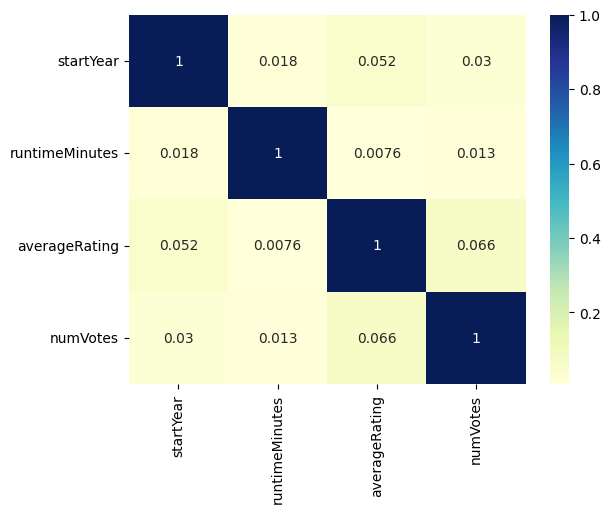

In [ ]:
# корреляционная матрица
sns.heatmap(df[['startYear', 'runtimeMinutes', 'averageRating', 'numVotes']].corr(), cmap="YlGnBu", annot=True)

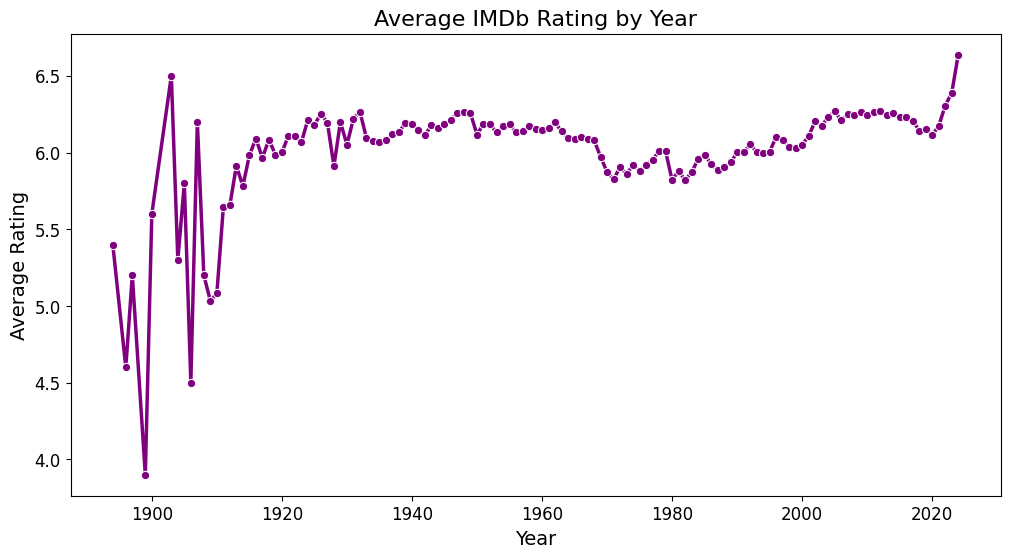

In [ ]:
# график зависимости среднего рейтинга фильмов от года выпуска
plt.figure(figsize=(12, 6))
average_rating_by_year = df.groupby('startYear')['averageRating'].mean().reset_index()
sns.lineplot(data=average_rating_by_year, x='startYear', y='averageRating', marker='o', linewidth=2.5, color = color)
plt.title('Average IMDb Rating by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Rating', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
df['runtimeMinutes'].sort_values().tail(15)

,runtimeMinutes
2396335,1440
1843031,1440
1646813,1452
964092,1500
938215,1620
1441695,2160
1176379,2880
1109804,5220
2245103,5460
1939600,9000


In [ ]:
top_20_runtime = df.nlargest(20, 'runtimeMinutes')[['originalTitle', 'runtimeMinutes']]
print(top_20_runtime)

                                           originalTitle  runtimeMinutes
2044502                                              100           59460
2435444                                        Logistics           51420
2155616                                         Ambiancé           43200
1990874                             Modern Times Forever           14400
1433694                                               Qw           10062
1939600                                     Beijing 2003            9000
2245103                                       London EC1            5460
1109804                            The Cure for Insomnia            5220
1176379  The Longest Most Meaningless Movie in the World            2880
1441695                                  Five-Year Diary            2160
938215                             Huo shao hong lian si            1620
964092                                              ****            1500
1646813                               Grandmother M

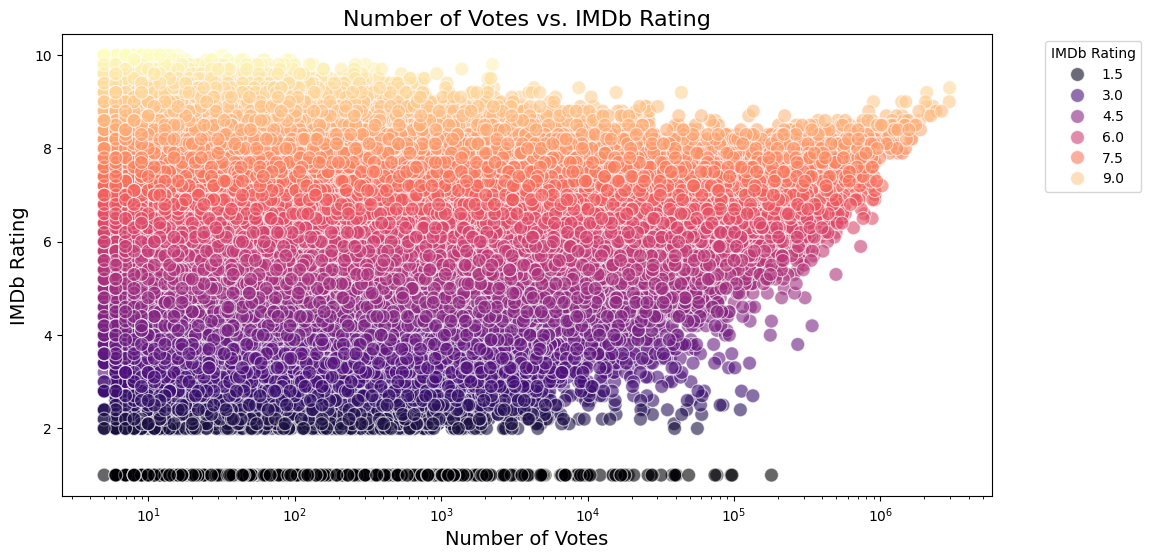

In [ ]:
# зависимость рейтинга и количества оценок на сайте IMDb
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='numVotes', y='averageRating', hue='averageRating', palette=palette, alpha=0.6, edgecolor='w', s=100)
plt.title('Number of Votes vs. IMDb Rating', fontsize=16)
plt.xlabel('Number of Votes', fontsize=14)
plt.ylabel('IMDb Rating', fontsize=14)
plt.xscale('log')
plt.legend(title='IMDb Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# гистограмма распределения года выпуска
sns.histplot(x=df['startYear'], bins=30, kde=True, color = color)

In [ ]:
# гистограмма распределения рейтинга
sns.histplot(x=df['averageRating'], bins=30, kde=True, color = color)

In [ ]:
# гистограмма распределения логарифма кол-ва голосов
plt.figure(figsize=(12, 6))
sns.histplot(x=np.log(df['numVotes']), bins=30, kde=True, color = color)
plt.title('Distribution of log(Number of Votes)', fontsize=16)
plt.xlabel('log(Number of Votes)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
# распределение рейтинга по семейным фильмам и фильмам 18+
sns.histplot(x=df[df['isAdult']==1]['averageRating'], bins=10, kde=True, color = color)

In [ ]:
sns.histplot(x=df[df['isAdult']==0]['averageRating'], bins=10, kde=True, color = color)

In [ ]:
df =pd.read_csv("df_unique.csv")

<ipython-input-58-5ffb1e80d896>:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df =pd.read_csv("df_unique.csv")


In [ ]:
# Преобразуем startYear в числовой формат
df['startYear'] = pd.to_numeric(df['startYear'], errors ='coerce')

# Преобразуем runtimeMinutes в числовой формат
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Создаем новую переменную "возраст фильма"
current_year = datetime.now().year
df['movie_age'] = current_year - df['startYear']

# Создаем дамми-переменную для длительности фильма
standard_length = 90
df['is_long_movie'] = (df['runtimeMinutes'] > standard_length).astype(int)

# Кодируем жанры в дамми-переменные
def check_genre(row, genre):
    # Если значение NaN, заменить на пустую строку
    if isinstance(row, float) and pd.isna(row):
        row = ''
    return 1 if genre in row else 0

# Применение функции для создания дамми-столбцов
df['Drama'] = df['genres'].apply(lambda x: check_genre(x, 'Drama'))
df['Comedy'] = df['genres'].apply(lambda x: check_genre(x, 'Comedy'))
df['Documentary'] = df['genres'].apply(lambda x: check_genre(x, 'Documentary'))

# Убираем пропущенные значения
df = df.dropna(subset=['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary', 'rating_5'])

# Разделим выборку на тестовую и обучающую
x = df[['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary']]
y = df['rating_5'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Уникальные значения по классам
value_counts = df['rating_5'].value_counts()
print(value_counts)

rating_5
4.0    130593
3.0    129261
2.0     35498
5.0     21061
1.0      4480
Name: count, dtype: int64


In [ ]:
# MNLogit для многоклассовой логистики
model = sm.MNLogit(y_train, sm.add_constant(X_train), )
result = model.fit()

# Вывод результатов
print(result.summary())

# Расчет предельных эффектов
marginal_effects = result.get_margeff()
print(marginal_effects.summary())


predictions = result.predict(sm.add_constant(X_test))
predicted_classes = np.argmax(predictions, axis=1)  # Индекс класса с максимальным значением вероятности


# Расчет метрик
print("Accuracy:", accuracy_score(y_test, predicted_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, predicted_classes))
print("Classification Report:\n", classification_report(y_test, predicted_classes))

Optimization terminated successfully.
         Current function value: 1.113849
         Iterations 9
                          MNLogit Regression Results                          
Dep. Variable:               rating_5   No. Observations:               224625
Model:                        MNLogit   Df Residuals:                   224597
Method:                           MLE   Df Model:                           24
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                 0.08279
Time:                        20:06:52   Log-Likelihood:            -2.5020e+05
converged:                       True   LL-Null:                   -2.7278e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
   rating_5=2       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.5901      0.035     45.993      0.000       1.522       1.658
movie_age         0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Обучим случайный лес
rf = RandomForestClassifier(max_depth    = 12,         # максимальная глубина деревьев
                            max_features = "sqrt",     # число случайно выбираемых при
                                                       # каждом разбиении признаков
                            max_samples  = 500,        # число бутстрап итераций
                            random_state = 777,        # для вопроизводимости
                            criterion    = 'entropy')  # критерий выбора признаков
                                                       # при разбиении узлов
rf.fit(X_train, y_train)


# Прогнозы
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

# Оценка точности на тестовой выборке
ACC_train_rf = accuracy_score(y_train, y_pred_train_rf)
ACC_test_rf = accuracy_score(y_test, y_pred_test_rf)

In [ ]:
#дерево решений
dt = DecisionTreeClassifier(
                               # максимальная глубина дерева
                               max_depth=10,
                               # минимальное число элементов в узле для разбиения (может быть долей)
                               min_samples_split=5,
                               # минимальное число элементов в листе (может быть долей)
                               min_samples_leaf=5)
                               # минимальное значение дельты impurity (примеси)
                               # min_impurity_decrease=0
dt.fit(X_train, y_train)

# Прогнозы
y_pred_train_dt = dt.predict(X_train)
y_pred_test_dt = dt.predict(X_test)

# Пример для неглубокого дерева
ACC_train_dt = accuracy_score(y_train, y_pred_train_dt)
ACC_test_dt = accuracy_score(y_test, y_pred_test_dt)

In [ ]:
results = pd.DataFrame(data={
    'Точность (обучение)': [ACC_train_dt, ACC_train_rf],
    'Точность (тест)': [ACC_test_dt, ACC_test_rf]
}, index=['Дерево решений', 'Случайный лес'])

print(results)

                Точность (обучение)  Точность (тест)
Дерево решений             0.537672         0.527727
Случайный лес              0.527209         0.524611


In [ ]:
dot_data = tree.export_graphviz(dt, out_file = None,
                      feature_names = ['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary'],
                      class_names = ['1', '2', '3', '4', '5'],
                      label='all',
                      filled=True,
                      impurity=True,
                      node_ids=True,
                      proportion=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
# вклад, значимость каждого показателя
pd.DataFrame({'feature': ['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary'],
              'importance': dt.feature_importances_}).sort_values('importance', ascending=False)

,feature,importance
5,Documentary,0.371827
1,numVotes,0.279811
0,movie_age,0.181829
3,Drama,0.100750
2,is_long_movie,0.044980
4,Comedy,0.020803


In [ ]:
x = df[['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary']]
y = df['rating_5'].astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)
# stratify - способ поддерживать баланс классов в обучающей и тестовой выборке

# обучаем модель на тренировочных данных
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

In [ ]:
confusion_matrix(y_pred, y_test)

array([[    0,     0,     0,     0,     0],
       [  220,   954,   617,   176,    39],
       [  794,  7574, 27194, 16298,  1259],
       [  328,  2116, 10929, 22537,  4903],
       [    2,     6,    38,   167,   117]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.45      0.56      0.50     39178
           2       0.36      0.32      0.34     39178
           3       0.37      0.35      0.36     39178
           4       0.48      0.25      0.33     39178
           5       0.51      0.70      0.59     39178

    accuracy                           0.44    195890
   macro avg       0.43      0.44      0.42    195890
weighted avg       0.43      0.44      0.42    195890



In [ ]:
# Балансировка классов: оверсэмплинг
ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x, y)

# Создание нового DataFrame из сбалансированных данных
df_resampled = pd.DataFrame(x_resampled, columns=x.columns)
df_resampled['rating_5'] = y_resampled

# Проверка распределения классов после балансировки
print("\nРаспределение классов после оверсэмплинга:")
print(Counter(df_resampled['rating_5']))


Распределение классов после оверсэмплинга:
Counter({3: 130593, 2: 130593, 4: 130593, 1: 130593, 5: 130593})


In [ ]:
x = df_resampled[['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary']]
y = df_resampled['rating_5'].astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)
# stratify - способ поддерживать баланс классов в обучающей и тестовой выборке

# обучаем модель на тренировочных данных
dt.fit(x_train, y_train)
rf.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
y_pred_rf = rf.predict(x_test)

In [ ]:
dt.score(x_test, y_test)

0.43329419572208894

In [ ]:
rf.score(x_test, y_test)

0.41998060135790494

In [ ]:
confusion_matrix(y_pred_dt, y_test)

array([[22433, 12518,  6789,  3981,  3412],
       [ 6211, 11928,  7863,  4062,  2326],
       [ 3946,  7908, 13872,  9163,  2519],
       [ 1118,  1896,  5080,  9932,  3051],
       [ 5470,  4928,  5574, 12040, 27870]])

In [ ]:
confusion_matrix(y_pred_rf, y_test)

array([[19517, 12077,  6190,  3309,  3076],
       [ 6699, 10937,  7427,  3875,  2186],
       [ 4763,  8458, 14085,  9365,  2795],
       [ 2068,  2463,  5636, 10608,  4031],
       [ 6131,  5243,  5840, 12021, 27090]])

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           1       0.46      0.57      0.51     39178
           2       0.37      0.30      0.33     39178
           3       0.37      0.35      0.36     39178
           4       0.47      0.25      0.33     39178
           5       0.50      0.71      0.59     39178

    accuracy                           0.44    195890
   macro avg       0.43      0.44      0.42    195890
weighted avg       0.43      0.44      0.42    195890



In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.44      0.50      0.47     39178
           2       0.35      0.28      0.31     39178
           3       0.36      0.36      0.36     39178
           4       0.43      0.27      0.33     39178
           5       0.48      0.69      0.57     39178

    accuracy                           0.42    195890
   macro avg       0.41      0.42      0.41    195890
weighted avg       0.41      0.42      0.41    195890



Оверсэмплинг не улучшил ситуацию

In [ ]:
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)

In [ ]:
# градиентный бустинг
# обучим модель
gb3 = XGBClassifier(n_estimators = 50,
                    max_depth = 3,
                    learning_rate = 0.5,
                    objective = 'binary:logistic',
                    random_state = 123)
gb3.fit(x_train, y_train_le)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
# Оценим условные вероятности градиентным бустингом
gb3_train = gb3.predict_proba(x_train)[:, 1]
gb3_test  = gb3.predict_proba(x_test)[:, 1]

In [ ]:
# Точность на тестовой выборке
ACC_test_gb3 = gb3.score(x_test, y_test)
ACC_test_gb3

0.1658124457603757

In [ ]:
confusion_matrix(y_pred, y_test)

array([[21691, 12266,  6473,  4174,  3797],
       [ 7499, 12677,  8574,  4487,  2368],
       [ 4062,  8274, 14406,  9644,  3129],
       [  962,  1576,  4528,  9480,  2908],
       [ 4964,  4385,  5197, 11393, 26976]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.20      0.22      0.21     39178
           2       0.20      0.17      0.18     39178
           3       0.20      0.21      0.20     39178
           4       0.20      0.13      0.16     39178
           5       0.20      0.27      0.23     39178

    accuracy                           0.20    195890
   macro avg       0.20      0.20      0.20    195890
weighted avg       0.20      0.20      0.20    195890



In [ ]:
x = df[['movie_age', 'numVotes', 'is_long_movie', 'Drama', 'Comedy', 'Documentary']]
y = df['rating_5'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

# Проверка размеров после андерсэмплинга
print("Размеры после андерсэмплинга:")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")



Размеры после андерсэмплинга:
X_train_balanced: (15720, 7)
y_train_balanced: (15720,)


In [ ]:
# Обучение модели RF
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, y_train_balanced)  # Используем сбалансированные данные

# Прогноз и оценка
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy}")

Точность модели: 0.3163771969917314


In [ ]:
#дерево решений
dt = DecisionTreeClassifier(
                               # максимальная глубина дерева
                               max_depth=10,
                               # минимальное число элементов в узле для разбиения (может быть долей)
                               min_samples_split=5,
                               # минимальное число элементов в листе (может быть долей)
                               min_samples_leaf=5)
                               # минимальное значение дельты impurity (примеси)
                               # min_impurity_decrease=0
dt.fit(X_train_balanced, y_train_balanced)
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy}")

Точность модели: 0.32377321643744544
